In [ ]:
import pandas as pd
 
# Cambia la ruta por el nombre de tu archivo CSV
ruta_csv = '../results/hvg_variance_metrics_with_indices_main_v3.csv'
df = pd.read_csv(ruta_csv)
 
# Guardar cada columna en una variable separada
columnas = df.columns.tolist()
 
# Ejemplo: guardar todas las columnas en variables individuales
for col in columnas:
    globals()[col] = df[col]
 
# Ahora puedes acceder a cada columna como una variable, por ejemplo:
# print(NOMBRE_DE_LA_COLUMNA)

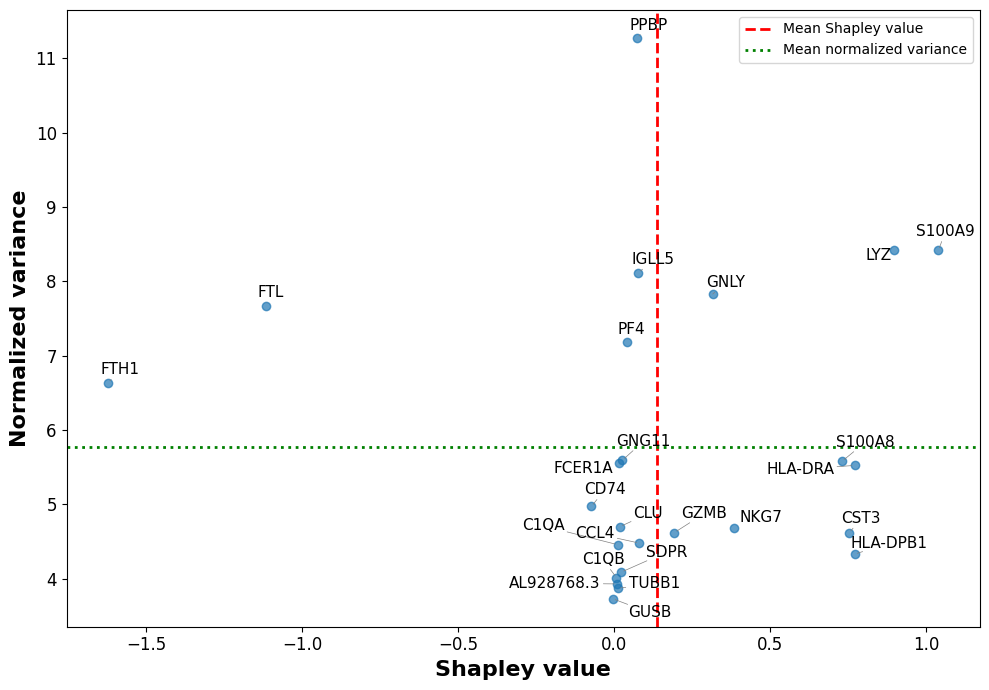

In [17]:
import matplotlib.pyplot as plt
from adjustText import adjust_text  # Necesario para evitar solapamiento de etiquetas

# X: Shapley, Y: normalized variance
x = df['Shapley']
y = df['variances_norm']
genes = df['gene'] if 'gene' in df.columns else None

plt.figure(figsize=(10,7))
plt.scatter(x, y, alpha=0.7)

# Etiquetar cada punto con el nombre del gen evitando solapamiento
texts = []
if genes is not None:
    for xi, yi, label in zip(x, y, genes):
        texts.append(plt.text(xi, yi, str(label), fontsize=11, ha='right', va='bottom'))
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Medias de las columnas
mean_x = x.mean()
mean_y = y.mean()

# Media Shapley (vertical, dashed red)
plt.axvline(mean_x, color='red', linestyle='--', linewidth=2, label='Mean Shapley value')

# Media normalized variance (horizontal, dotted green)
plt.axhline(mean_y, color='green', linestyle=':', linewidth=2, label='Mean normalized variance')

plt.xlabel('Shapley value', fontsize=16, fontweight='bold')
plt.ylabel('Normalized variance', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()